In [42]:
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn.functional as F


In [43]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        # transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

data = datasets.MNIST(
    root='data', # location specify karne ke liye hai i.e folder name tere hisab se bhi rak sakte ho
    train= True,
    download= True,
    transform=transform
)
data[0][0].size()

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [44]:
train_loader = DataLoader(data, 64, True)
test_loader = DataLoader(test_data, 64, shuffle=False)

# ----------------------------------CNN TEMPLATE -------------------------
# CNN for image classification
# class CNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=3, padding=1), # 28×28→28×28
#             nn.ReLU(),
#             nn.MaxPool2d(2),                            # 28×28→14×14
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),# 14×14→14×14
#             nn.ReLU(),
#             nn.MaxPool2d(2),                            # 14×14→7×7
#         )
#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(64 * 7 * 7, 128),
#             nn.ReLU(),
#             nn.Linear(128, 10)
#         )
#     def forward(self, x):
#         return self.fc(self.conv(x))

In [45]:
class cnnmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, #1 image
                        out_channels= 6, # 6 different filters 
                        kernel_size=3, #3x3 matrix
                        stride=1, #1 step at a time
                        )# this outpur will become inpput for next one
        self.conv2 = nn.Conv2d(6,16,3,1)
        # after convo and pooling 5 layer banega with 16 features each so 5x5x16 
        # template mai 7x7x coz 7 layer and 64 features so 7x7x64  
        self.layer1 = nn.Linear(5*5*16, 128)
        self.output = nn.Linear(128, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,2,2) #kernel and stride size 
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2,2)
        x = x.view(-1, 5*5*16)
        x = F.relu(self.layer1(x))
        return F.log_softmax(self.output(x), dim=1)

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = cnnmodel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)
# device

In [48]:

for epoch in range(10):
    # pred = model.train()
    losses  = 0
    for image,labels in train_loader:
        model.zero_grad()
        image = image.to(device)
        labels = labels.to(device)
        
        output = model(image)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()
        
        losses += loss.item()
    print(
        f"Epoch {epoch+1}, Loss: {losses:.4f}"
    )
        
            

Epoch 1, Loss: 132.0943
Epoch 2, Loss: 72.7791
Epoch 3, Loss: 52.8299
Epoch 4, Loss: 43.1726
Epoch 5, Loss: 36.1206
Epoch 6, Loss: 30.8102
Epoch 7, Loss: 25.4506
Epoch 8, Loss: 21.0979
Epoch 9, Loss: 19.2578
Epoch 10, Loss: 16.6843


In [50]:
model.eval()
wrong = []
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        mismatch = predicted != labels

        for img, true_label, pred_label in zip(
            images[mismatch], labels[mismatch], predicted[mismatch]
        ):
            wrong.append((img.cpu(), true_label.item(), pred_label.item()))

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")
print("Number of wrong predictions:", len(wrong))

Accuracy: 98.82%
Number of wrong predictions: 118


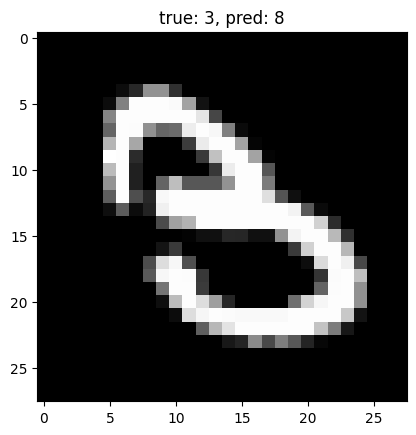

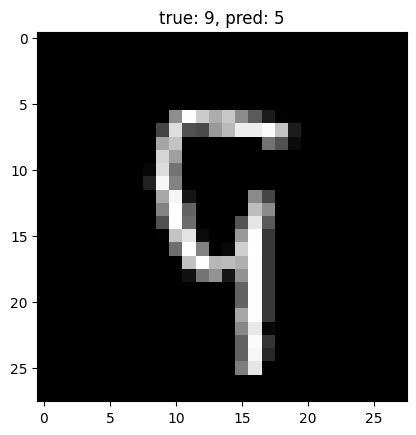

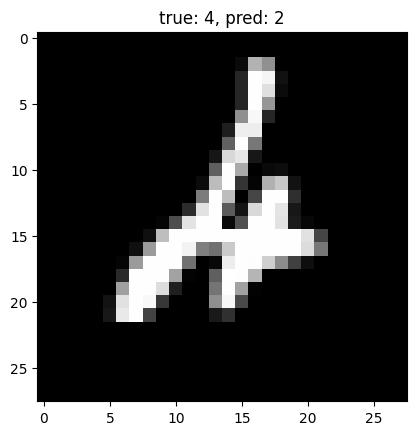

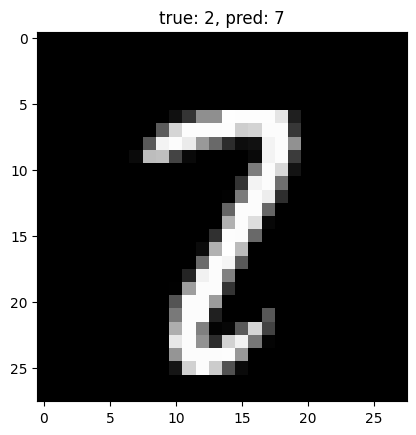

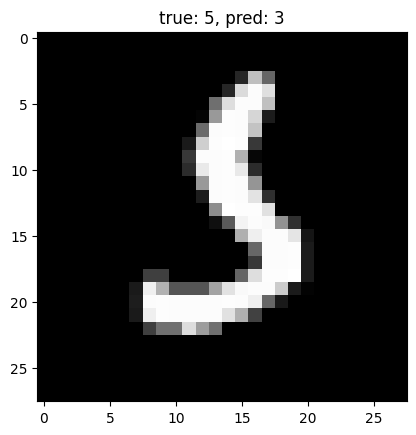

In [55]:
for i in wrong[:5]:
    img, true_label, pred_label = i
    plt.Figure()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"true: {true_label}, pred: {pred_label}")
    plt.show()